### 17.2.2 遗传算法应用  

**例 17.2 (续例 17.1)** 用遗传算法求解例 17.1.  


#### 1. 模型及算法  
遗传算法求解的参数设定如下：种群大小 $ M = 50 $；最大代数 $ G = 10 $. 交叉概率 $ p_c = 1 $，交叉概率为 1 能保证种群的充分进化；变异概率 $ p_m = 0.1 $，一般而言，变异发生的可能性较小.  


##### 1) 编码策略  
采用十进制编码，用随机序列 $ \omega_0, \omega_1, \cdots, \omega_{101} $ 作为染色体，其中 $ 0 < \omega_i < 1 $（$ i = 1, 2, \cdots, 100 $），$ \omega_0 = 0 $，$ \omega_{101} = 1 $；每一个随机序列都和种群中的一个个体相对应，例如，9 个目标问题的一个染色体为  
$$
[0.23,\ 0.82,\ 0.45,\ 0.74,\ 0.87,\ 0.11,\ 0.56,\ 0.69,\ 0.78],
$$  
其中编码位置 $ i $ 代表目标 $ i $，位置 $ i $ 的随机数表示目标 $ i $ 在巡回中的顺序，将这些随机数按升序排列得到如下巡回：  
$$
6 \rightarrow 1 \rightarrow 3 \rightarrow 7 \rightarrow 8 \rightarrow 4 \rightarrow 9 \rightarrow 2 \rightarrow 5.
$$  


##### 2) 初始种群  
先利用经典的近似算法 —— 改良圈算法求得一个较好的初始种群. 对于随机产生的初始圈  
$$
\begin{align*}
C &= \pi_0 \cdots \pi_{u-1} \pi_u \pi_{u+1} \cdots \pi_{v-1} \pi_v \pi_{v+1} \cdots \pi_{101}, \\
&1 \leqslant u < v \leqslant 100,\quad 1 \leqslant \pi_u < \pi_v \leqslant 100,
\end{align*}
$$  
交换 $ u $ 与 $ v $ 之间的顺序，此时的新路径为  
$$
\pi_0 \cdots \pi_{u-1} \pi_v \pi_{v-1} \cdots \pi_{u+1} \pi_u \pi_{v+1} \cdots \pi_{101}.
$$  

记 $ \Delta f = (d_{\pi_{u-1} \pi_v} + d_{\pi_u \pi_{v+1}}) - (d_{\pi_{u-1} \pi_u} + d_{\pi_v \pi_{v+1}}) $，若 $ \Delta f < 0 $，则以新路径修改旧路径，直到不能修改为止，就得到一个比较好的可行解.  

直到产生 $ M $ 个可行解，并把这 $ M $ 个可行解转换成染色体编码.  


##### 3) 目标函数  
目标函数为侦察所有目标的路径长度，适应度函数就取为目标函数. 我们要求  
$$
\min\ f(\pi_0, \pi_1, \cdots, \pi_{101}) = \sum_{i=0}^{100} d_{\pi_i \pi_{i+1}}.
$$  


##### 4) 交叉操作  
交叉操作采用单点交叉. 设计如下，对选定的两个父代个体 $ f_1 = \omega_0 \omega_1 \cdots \omega_{101} $，$ f_2 = \omega_0' \omega_1' \cdots \omega_{101}' $，随机地选取第 $ t $ 个基因处为交叉点，则经过交叉运算后得到的子代个体为 $ s_1 $ 和 $ s_2 $ 。$ s_1 $ 的基因由 $ f_1 $ 的前 $ t $ 个基因和 $ f_2 $ 的后 $ 102-t $ 个基因构成；$ s_2 $ 的基因由 $ f_2 $ 的前 $ t $ 个基因和 $ f_1 $ 的后 $ 102-t $ 个基因构成，例如，  
$$
\begin{align*}
f_1 &= [0,\ 0.14,\ 0.25,\ 0.27,\ \vert 0.29,\ 0.54,\ \cdots,\ 0.19,\ 1], \\
f_2 &= [0,\ 0.23,\ 0.44,\ 0.56,\ \vert 0.74,\ 0.21,\ \cdots,\ 0.24,\ 1],
\end{align*}
$$  
设交叉点为第 4 个基因处，则  
$$
\begin{align*}
s_1 &= [0,\ 0.14,\ 0.25,\ 0.27,\ \vert 0.74,\ 0.21,\ \cdots,\ 0.24,\ 1], \\
s_2 &= [0,\ 0.23,\ 0.44,\ 0.56,\ \vert 0.29,\ 0.54,\ \cdots,\ 0.19,\ 1].
\end{align*}
$$  
交叉操作的方式有很多种选择，应该尽可能选取好的交叉方式，保证子代能继承父代的优良特性.  


##### 5) 变异操作  
变异也是实现群体多样性的一种手段，同时也是全局寻优的保证. 具体设计如下，按照给定的变异概率，对选定变异的个体，随机地取三个整数，满足 $ 1 \leqslant u < v < w \leqslant 100 $，把 $ u, v $ 之间（包括 $ u $ 和 $ v $）的基因段插到 $ w $ 后面.  


##### 6) 选择  
采用确定性的选择策略，也就是说在父代种群和子代种群中选择目标函数值最小的 $ M $ 个个体进化到下一代，这样可以保证父代的优良特性被保存下来.  




#### 2. 模型求解  
利用 Python 软件，求得的巡航时间在 $ 42\mathrm{h} $ 左右，其中的一个巡航路径如图 17.2 所示.

In [12]:

import pandas as pd

df = pd.read_csv("实际距离数据.txt", delimiter=' ')
df.to_excel('实际距离数据.xlsx')
df

,7.000000000000000000e+01,4.000000000000000000e+01,9.492039680480957031e-05,3.167631124414297574e+03,4.835684922021096099e+03,2.526708186347585070e+03,5.389235357043722615e+03,2.426952519668051082e+03,6.245136343904564455e+03,4.785126766760898136e+03,...,3.047920104746200195e+03,6.122194903814473946e+03,3.740122343730214652e+03,4.859375093174647191e+03,3.526914199935073157e+03,7.736724038675939482e+03,3.580909313550202114e+03,5.665392383639232321e+03,2.978024331208164767e+03,9.492039680480957031e-05.1
0,53.7121,15.3046,3167.631124,0.000000,1720.648593,1630.099426,2712.042222,742.428552,4581.764660,3352.876765,...,2048.762760,4960.988201,1709.116441,3114.749917,2016.359631,5586.682778,1539.528902,3290.902267,1895.396843,3167.631124
1,51.1758,0.0322,4835.684922,1720.648593,0.000000,3182.192669,2435.741826,2448.021590,4777.033906,3998.079228,...,3383.641939,5419.235648,2622.740135,3616.954182,3109.785305,5236.092959,2553.534519,3184.099055,3259.660694,4835.684922
2,46.3253,28.2753,2526.708186,1630.099426,3182.192669,0.000000,2908.019061,1281.068917,3872.242866,2422.716424,...,647.013568,3962.896162,1225.553808,2398.673524,1023.932772,5259.426802,1085.073084,3138.709535,515.867857,2526.708186
3,30.3313,6.9348,5389.235357,2712.042222,2435.741826,2908.019061,0.000095,3242.926613,2361.299244,1970.349379,...,2584.243228,3079.593263,1689.402856,1536.242512,2067.453041,2927.518667,1823.740991,750.054620,2574.243956,5389.235357
4,56.5432,21.4188,2426.952520,742.428552,2448.021590,1281.068917,3242.926613,0.000000,4829.121378,3470.433255,...,1864.293399,5076.163256,1898.671452,3321.062179,2027.023611,6004.849947,1707.850152,3725.696750,1708.535859,2426.952520
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,4.1591,3.1853,7736.724039,5586.682778,5236.092959,5259.426802,2927.518667,6004.849947,1625.085246,2987.080639,...,4691.262266,2243.791165,4149.704831,2877.760028,4235.898540,0.000000,4336.944053,2296.455032,4772.438437,7736.724039
97,40.1400,20.3030,3580.909314,1539.528902,2553.534519,1085.073084,1823.740991,1707.850152,3123.641524,1817.948985,...,903.489331,3430.931693,191.048210,1619.565972,558.301780,4336.944053,0.000000,2114.029368,829.871601,3580.909314
98,23.9876,9.4030,5665.392384,3290.902267,3184.099055,3138.709535,750.054620,3725.696750,1616.864786,1528.627765,...,2677.704270,2369.407032,1938.983703,1136.570803,2163.423880,2296.455032,2114.029368,0.000000,2713.132827,5665.392384
99,41.1084,27.7149,2978.024331,1895.396843,3259.660694,515.867857,2574.243956,1708.535859,3360.496532,1907.536151,...,157.686362,3450.977292,903.179102,1899.936730,551.663791,4772.438437,829.871601,2713.132827,0.000000,2978.024331


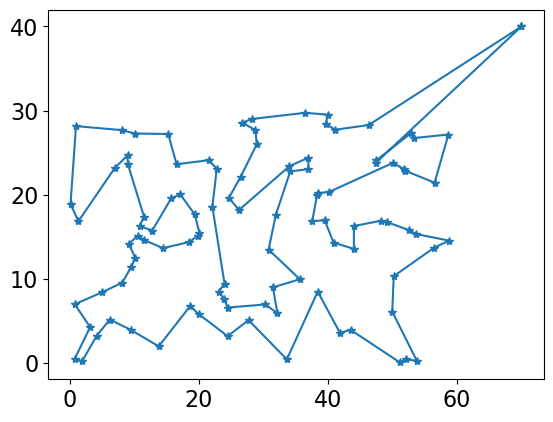

所求的巡航路径长度为:
44346.164493884644
路径为:
[  0  31  78  76  34  61   5  38  66  68  98  16  94  53  62  73  14  91
  28  44  64   1  74  63  24  86  83  49   2  33  32  65  84  36  55  72
  75  69  47  43  97  10  30  59  56  40  25  50   8  82  23  48  57  60
  58   9  87  45  89  39   6  90  67  21  93  85  27  20  81  79  42  22
  41   7  26  99  71  37  51   4  18  12  54  35  29  46  88  96  70  13
  95  11  15  80  52  17  19  77  92 100   3 101]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

a = np.loadtxt("Pdata17_2.txt")
xy, d = a[:, :2], a[:, 2:]  #  a[:, :2]读取0，1两列x，y坐标(102, 2),a[:, 2:]读取(102, 102)距离矩阵
N = len(xy)  # 102
w = 50  # 种群个数
g = 10  # 最大进化代数
J = []  # 存储所有种群

# 生成50个种群
for i in np.arange(w):
    c = np.arange(1, N-1)  # 1~100 101不包括
    np.random.shuffle(c)  # 打乱形成路径（1~100内）
    c1 = np.r_[0, c, 101]  # 加入起点0和终点101
    flag = 1
    while flag > 0:  # flag帮助进行循环，无具体含义,for循环次数达到后退出循环
        flag = 0
        # 2-opt交换，起点0和终点101不变
        for m in np.arange(1, N-3):  # 1~98,保证m+1最多等于99，n和n+1不超过100(<=100)
            for n in np.arange(m+1, N-2):  # m+1 ~ 99,保证n+1存在且最大=100
                if d[c1[m], c1[n]] + d[c1[m+1], c1[n+1]] < d[c1[m], c1[m+1]] + d[c1[n], c1[n+1]]:  # 判断逆序后的距离 < 逆序前的距离==delta f < 0
                    c1[m+1:n+1] = c1[n:m:-1]  # 逆序操作,[m+1, n]=[n, m+1]
                    flag = 1
    # 规范化路径一直是[0, 1, 2, ···, 99, 100, 101]，但是实际路径已经发生改变，对应的在数组中的位置才是城市的点号，如0-->1，1在数组的第58个位置，那它就是第57号点
    c1[c1] = np.arange(N)  # 花式索引(重映射)
    J.append(c1)  # 每次w变化一次，产生一个种群，共50个, 列表的每个元素是一个array数组
J = np.array(J) / (N-1)  # np.array(J)将J转化为二维数组(50, 102)，每一行是一个路径(种群)，0~101除以101，归一化，表示成染色体，路径就是从最小的数排到最大的数，对应0~101

# 进化10代/适者生存
for k in np.arange(g):  # 每次迭代J的形状改变，A随之改变
    
    # 交叉
    A = J.copy()  # A存储交叉后的染色体（路径），A最终为(50, 102), 保留原始种群以便后续比较（例如选择最优路径）
    c1 = np.arange(w)  # 0~49
    np.random.shuffle(c1)  # 交叉操作的染色体配对组，c1[i]和c[i+1]配对，发生交叉
    c2 = np.random.randint(2, 100, w)  # w=50个交叉点数据，即从当前点到100号点交叉
    for i in np.arange(0, w, 2):  # w已经打乱，取偶数是因为交叉成对进行，避免重复，相邻两个染色体(奇数和偶数)进行交叉(生物上:基因重组),从0开始保证i=48时，i+1=49存在
        temp = A[c1[i], c2[i]:N-1]  # 保存中间变量
        A[c1[i], c2[i]:N-1] = A[c1[i+1], c2[i]:N-1]  # c1[i]就是A的第c1[i]行，是一个染色体，c2[i]:N-1切片操作，[c2[i], N-2]包括N-2=100
        A[c1[i+1], c2[i]:N-1] = temp
    
    # 变异
    B = A.copy()
    by = []  # 初始化变异染色体的序号
    while len(by) < 1:  # 确保至少有一个变异染色体
        by = np.where(np.random.rand(w) < 0.1)  # 返回np.random.rand(w) < 0.1的元素的索引
    by = by[0]  # (array([20, 22, 37, 45], dtype=int64),)，取索引，即变异点
    B = B[by, :]  # 形状(len(by), 102), by上一行代码已经改变为一维数组
    G = np.r_[J, A, B]  # (50+50+len(by), 102)
    # np.argsort()返回数组排序后的索引,np.sort返回排序后的数组
    ind = np.argsort(G, axis=1)  # 染色体恢复0~101，路径0-->1-->2···-->100-->101，形状与G一致，(len(by)+100, 102)
    NN = G.shape[0]  # 原始种群数50+交叉后种群数50+变异的种群数目len(by)
    L = np.zeros(NN)  # (50+50+len(by),)，最终为(50+50+len(by),)，每一个数都是染色体(路径的长度)
    for j in np.arange(NN):  # 0~50+50+len(by)-1
        for i in np.arange(101):  # 0~100
            L[j] = L[j] + d[ind[j, i], ind[j, i+1]]  # i从0~100，i+1从1~101每个染色体(路径0,1,2,···,100,101)的总长度，d[ind[j, i], ind[j, i+1]]路径上相邻对应点的距离
    ind2 = np.argsort(L)  # 路径长度排序索引
    
    # 选择，注意：此处没有阶段，即没有进行选择/适者生存,ind2改为ind2[:50]截断选择
    J = G[ind2[:50], :]  # 花式索引，使用 ind2 作为索引，对 G 的行进行重新排序
    
# 路径和最短距离
path = ind[ind2[0], :]
zL = L[ind2[0]]

# 画图x，y坐标
xx = xy[path, 0]
yy = xy[path, 1]

plt.rcParams['font.size'] = 16
plt.plot(xx, yy, '*-')
plt.show()

print(f"所求的巡航路径长度为:\n{zL}")
print(f"路径为:\n{path}")